# Lab 1: Machine Learning (التعلم الآلي) Learns Numbers

Welcome to your first Machine Learning (التعلم الآلي) Lab! In this activity, we will explore **Linear Regression (الانحدار الخطي)**. 

Our goal is to understand how a model "learns" the coefficients (weights) to make accurate predictions.

## Setup dependencies
First, let's bring in the tools we need. Run the cell below to load them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider

# Use a clean style for our plots
sns.set_theme(style="whitegrid")
print("All libraries loaded successfully!")

All libraries loaded successfully!


## Create "Toy" Data

Instead of loading a massive dataset, let's create 5 fictional houses. We'll give each a size (Square Feet) and a Price (in thousands of dollars).

,SqFt,Beds,Baths,Price
0,800,2,1.0,150
1,1500,3,2.0,300
2,2000,3,2.5,400
3,2500,4,3.0,450
4,3000,4,3.5,500


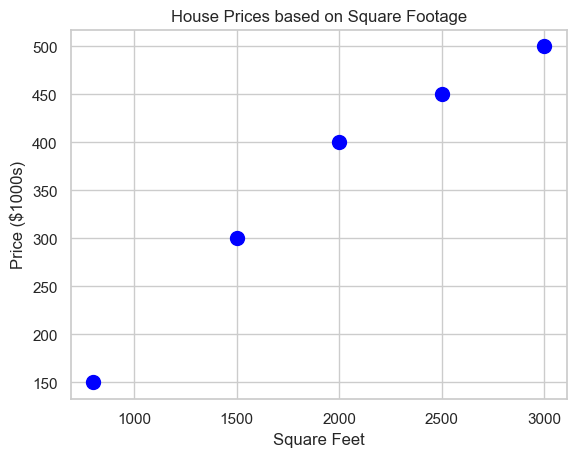

In [2]:
# A simple DataFrame containing our synthetic houses
data = pd.DataFrame({
    "SqFt": [800, 1500, 2000, 2500, 3000],
    "Beds": [2, 3, 3, 4, 4],     # we can expand to use this later
    "Baths": [1, 2, 2.5, 3, 3.5], # we can expand to use this later
    "Price": [150, 300, 400, 450, 500] # Target ($1000s)
})

# Let's peek at our data
display(data)

# Let's plot our initial variables
plt.scatter(data['SqFt'], data['Price'], color='blue', s=100)
plt.title("House Prices based on Square Footage")
plt.xlabel("Square Feet")
plt.ylabel("Price ($1000s)")
plt.show()

## You Be The Algorithm! (Manual Fitting)

Our goal is to draw the **best line** through these dots to predict price based on square footage. The equation for a line is:

$\text{Price} = b + w \times \text{SqFt}$

- $b$ represents the **bias** or starting point (Y-intercept).
- $w$ represents the **weight** given to one square foot of house.

Let's see if you can find the best combination manually. Run the block, change the sliders, and try to make the **Average Error** as small as possible.

In [ ]:
# A simple function to plot lines and calculate error

def plot_and_calculate_error(bias, weight):
    print(f"Equation: Price = {bias} + {weight} * SqFt")
    
    # Let's see what prices our custom line predicts
    data['Predicted_Price'] = bias + weight * data['SqFt']
    
    # Plot original data points
    plt.scatter(data['SqFt'], data['Price'], color='blue', s=100)
    
    # Plot our predicted line
    plt.plot(data['SqFt'], data['Predicted_Price'], color='red')
    
    # Plot error lines (residuals)
    for index, row in data.iterrows():
        plt.plot([row['SqFt'], row['SqFt']], 
                 [row['Price'], row['Predicted_Price']], 
                 color='yellow', linestyle='--')
                 
    plt.title("Manual Line Fit")
    plt.xlabel("Square Feet")
    plt.ylabel("Price ($1000s)")
    plt.show()
    
    # Calculate Mean Absolute Error (MAE)
    average_error = ((data['Price'] - data['Predicted_Price']).abs()).mean()
    print(f"Average Error (Difference between real and predicted): ± {average_error:.2f}")

# Make it interactive using sliders
interaction = interact(
    plot_and_calculate_error,
    bias=FloatSlider(value=0, min=-50, max=200, step=5, description="Bias (b)"),
    weight=FloatSlider(value=0.01, min=0.00, max=0.5, step=0.01, description="Weight (w1)")
);

interactive(children=(FloatSlider(value=0.0, description='Bias (b)', max=200.0, min=-50.0, step=5.0), FloatSli…

## Finding The Math With sklearn

How close did you get? 

Finding these answers manually requires guesswork and gets impossible when we start looking at more features like Bedrooms and Bathrooms simultaneously. That's why we use an algorithm! Python's `scikit-learn` package has built a highly-optimized machine-learning function to do exactly what you just did manually. Let's let the computer find the absolute easiest line.

In [4]:
# Import our "Machine Learning Algorithm"
from sklearn.linear_model import LinearRegression

# We organize our features (Inputs 'X') and Targets (Output 'Y')
X = data[['SqFt']] # X needs to be a 2D grouping
y = data['Price']

# 1. Initialize our learner
model = LinearRegression()

# 2. Tell the algorithm to "Fit" the line -- Here is the "Learning"!
model.fit(X, y)

# 3. Analyze what it learned
best_bias = model.intercept_
best_weight = model.coef_[0]

print(f"Optimal Bias (b): {best_bias:.2f}")
print(f"Optimal Weight (w1): {best_weight:.4f}")
print(f"The Best Equation: Price = {best_bias:.2f} + ({best_weight:.4f} * SqFt)")

# Compare with your results using the slider above!

Optimal Bias (b): 47.82
Optimal Weight (w1): 0.1593
The Best Equation: Price = 47.82 + (0.1593 * SqFt)


## Advanced Try: Multiple Linear Variables
Wait, what if we use bedrooms and bathrooms?
Machine Learning (التعلم الآلي) algorithms shine exactly because they can handle massive dimensions we could never plot on a 2D piece of paper!

In [5]:
# More Features!
X_multi = data[['SqFt', 'Beds', 'Baths']]

# Train
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("What the Machine Learned:")
print(f"Base Price (b): {model_multi.intercept_:.2f}")
print("Added Value Per Feature:")

# Let's cleanly print what weight the model attached to each column
for feature, weight in zip(X_multi.columns, model_multi.coef_):
    print(f" * Every extra {feature} adds {weight:.2f}")


What the Machine Learned:
Base Price (b): 25.00
Added Value Per Feature:
 * Every extra SqFt adds -0.12
 * Every extra Beds adds -25.00
 * Every extra Baths adds 275.00
